# Case iFood — Melhoria dos Modelos (Feature Engineering + Tuning)

Integrantes: Arthur Costa Donaire (RM571283) · Felipe Pereira de Jesus (RM573263) ·
Giovanna Pereira de Oliveira (RM570989) · Gustavo Paiva Silva (RM572249) ·
Maria Eduarda Soares Lopes e Souza (RM572612)



---



Este notebook parte dos 3 notebooks apresentados em aula (baselines, boosting e tuning) e busca
**superar o melhor ROC AUC visto em aula** por meio de:

1. EDA objetiva e criação de novas features, com justificativa;
2. Preparação dos dados com HoldOut estratificado (o conjunto de teste só é usado na avaliação final);
3. Tuning de hiperparâmetros com validação cruzada, usando os mesmos modelos e técnicas de busca
   já vistos em aula (Grid Search, Randomized Search, Bayesian Search);
4. Comparação final entre os modelos da aula e os novos modelos, usando Precision, Recall,
   F1-score e ROC AUC.

**Referência da aula (melhor resultado):** CatBoost (baseline, sem tuning), ROC AUC = **0.912211**.

No notebook de tuning da aula (Part 3), as buscas usaram
`scoring="precision"`. Isso fez os modelos tunados terem AUC *pior* que o baseline do Part 2.
Como o desafio aqui é de ROC AUC, todas as buscas abaixo usam `scoring="roc_auc"`.

## 1. Importação das bibliotecas

In [1]:
# Bibliotecas usadas em aula (algumas já vêm instaladas no Colab; garantimos aqui as demais)
!pip install -q lightgbm xgboost catboost scikit-optimize

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from skopt import BayesSearchCV
from skopt.space import Integer, Real

from scipy.stats import randint, uniform

SEED = 42
np.random.seed(SEED)

TARGET = "Response"
BASELINE_AUC = 0.912211  # melhor ROC AUC da aula (CatBoost, Part 2, baseline)

## 2. Carregamento dos dados

In [3]:
POSSIBLE_PATHS = ["data.csv", "data_1.csv", "/content/data.csv", "/content/data_1.csv"]
DATA_PATH = next((p for p in POSSIBLE_PATHS if os.path.exists(p)), None)

if DATA_PATH is None:
    try:
        from google.colab import files
        print("Arquivo não encontrado automaticamente. Faça o upload do CSV do case (ex.: data.csv):")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
    except ImportError:
        raise FileNotFoundError("Ajuste DATA_PATH manualmente para o caminho do CSV do case.")

df = pd.read_csv(DATA_PATH)
print("Dados carregados de:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Arquivo não encontrado automaticamente. Faça o upload do CSV do case (ex.: data.csv):


Saving data (1).csv to data (1).csv
Dados carregados de: data (1).csv
Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


## 3. EDA

Focada nos tipos de dado, valores ausentes,
desbalanceamento do target, outliers e quais variáveis mais se relacionam com a resposta.

### 3.1 Verificação de dados ausentes

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [5]:
nulos = df.isnull().sum()
nulos[nulos > 0]

,0
Income,24


**Achado:** `Income` tem 24 valores ausentes (~1% da base). Será tratado por imputação
(mediana) dentro do pipeline, igual em aula.

### 3.2 Balanceamento da target

In [6]:
df[TARGET].value_counts(normalize=True).rename("proporcao")

,proporcao
Response,
0,0.850893
1,0.149107


**Achado:** apenas ~15% dos clientes responderam à campanha (`Response=1`). O dataset é
desbalanceado — por isso o foco em Precision/Recall/F1/AUC, e não apenas em acurácia.

### 3.3 Outliers

In [7]:
#Variáveis numéricas-chave
df[["Year_Birth", "Income"]].describe()

,Year_Birth,Income
count,2240.000000,2216.000000
mean,1968.805804,52247.251354
std,11.984069,25173.076661
min,1893.000000,1730.000000
25%,1959.000000,35303.000000
50%,1970.000000,51381.500000
75%,1977.000000,68522.000000
max,1996.000000,666666.000000


In [8]:
print("Clientes com Year_Birth < 1920 (idade > ~107 anos):", (df["Year_Birth"] < 1920).sum())
print("Clientes com Income > 200.000:", (df["Income"] > 200000).sum())

Clientes com Year_Birth < 1920 (idade > ~107 anos): 3
Clientes com Income > 200.000: 1


**Achado:** 3 clientes têm `Year_Birth` em 1893/1899/1900 (idade acima de 110 anos) e 1 cliente
tem `Income` de 666.666 (~13x o terceiro quartil). São 4 registros em 2240, portanto serão removidos na limpeza, antes do split.

In [9]:
#Variáveis categóricas
df["Marital_Status"].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


**Achado:** `Alone`, `Absurd` e `YOLO` somam só 7 registros e não são categorias válidas de
estado civil. Serão agrupadas em `Other` para não virarem ruído no One-Hot Encoding.

### 3.4 Correlação com variável target

In [10]:
# Correlação simples das variáveis numéricas com o target, para orientar a criação de features
corr_target = (
    df.select_dtypes(include=np.number) #separa apenas colunas numéricas
    .corr(numeric_only=True)[TARGET] #matriz de correlação de Pearson entre todas as colunas numéricas
    .drop(TARGET) #pega a coluna referente à correlação de cada variável com Response (alvo)
    .sort_values(ascending=False)
)
corr_target.head(10) #ordem de correlação da maior para menor
#mede apenas a relação linear de cada coluna soxinha com o target, sem capturar interações (univariada)

#AcceptedCmp = campanhas anteriores aceitas
#Mnt = gasto por categoria

,Response
AcceptedCmp5,0.326634
AcceptedCmp1,0.293982
AcceptedCmp3,0.254258
MntWines,0.247254
MntMeatProducts,0.236335
NumCatalogPurchases,0.220810
AcceptedCmp4,0.177019
AcceptedCmp2,0.169293
NumWebPurchases,0.148730
MntGoldProds,0.139850


**Achado:** as variáveis mais correlacionadas com a resposta
são gastos por categoria (`MntWines`, `MntMeatProducts`, ...), compras por catálogo
(`NumCatalogPurchases`) e aceitação de campanhas anteriores (`AcceptedCmp5`, `AcceptedCmp1`,
`AcceptedCmp3`). Ou seja: **quanto o cliente gasta/compra** e **se ele já aceitou campanhas antes**
parecem ser os sinais mais fortes (justifica criar variáveis agregadas).

## 4. Feature Engineering

Novas features, diretamente ligadas ao que a EDA mostrou:

- **Limpeza de outliers de cadastro:** remoção dos 4 registros com `Year_Birth` ou `Income`
  claramente errados.
- **`Age`** = ano de referência do case (2017) − `Year_Birth` (mesma lógica usada em aula).
- **`Days_Customer`** = dias entre o cadastro (`Dt_Customer`) e a data mais recente da base
  (mesma lógica usada em aula).
- **`Marital_Status` agrupado**: categorias raras (`Alone`, `Absurd`, `YOLO`) viram `Other`.
- **`TotalMnt`** = soma de todos os `Mnt*` (gasto total do cliente). Direto da correlação encontrada.
- **`TotalPurchases`** = soma de `NumDealsPurchases + NumWebPurchases + NumCatalogPurchases +
  NumStorePurchases` (quantidade total de compras, por qualquer canal).
- **`TotalAcceptedCmp`** = soma de `AcceptedCmp1..5` (quantas campanhas anteriores o cliente já
  aceitou — o sinal mais forte de propensão a aceitar de novo).
- **`Kids_Total`** = `Kidhome + Teenhome`; **`Has_Child`** = indicador binário (tem filho ou não).
- **`AvgTicket`** = `TotalMnt / (TotalPurchases + 1)` (ticket médio por compra).
- **`Family_Size`** = 1 + (1 se `Married`/`Together`) + `Kids_Total`.
- **`Income_per_Person`** = `Income / Family_Size` (poder de compra per capita, não só da família).

Colunas descartadas: `ID` (identificador, sem valor preditivo), `Dt_Customer` (já virou
`Days_Customer`), `Year_Birth` (já virou `Age`), `Z_CostContact` e `Z_Revenue` (constantes em
toda a base — variância zero, não carregam informação).

In [11]:
df_fe = df.copy()

# Limpeza dos outliers
df_fe = df_fe[df_fe["Year_Birth"] >= 1920]
df_fe = df_fe[(df_fe["Income"].isna()) | (df_fe["Income"] < 200000)]

# Idade e tempo de casa
REF_YEAR = 2017
df_fe["Age"] = REF_YEAR - df_fe["Year_Birth"]

df_fe["Dt_Customer"] = pd.to_datetime(df_fe["Dt_Customer"], errors="coerce")
ref_date = df_fe["Dt_Customer"].max()
df_fe["Days_Customer"] = (ref_date - df_fe["Dt_Customer"]).dt.days

# Agrupamento de categorias raras
df_fe["Marital_Status"] = df_fe["Marital_Status"].replace(["Alone", "Absurd", "YOLO"], "Other")

# Features agregadas de gasto, compras e campanhas
mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
purchase_cols = ["NumDealsPurchases", "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
cmp_cols = ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"]

df_fe["TotalMnt"] = df_fe[mnt_cols].sum(axis=1)
df_fe["TotalPurchases"] = df_fe[purchase_cols].sum(axis=1)
df_fe["TotalAcceptedCmp"] = df_fe[cmp_cols].sum(axis=1)

# Features de composição familiar e poder de compra
df_fe["Kids_Total"] = df_fe["Kidhome"] + df_fe["Teenhome"]
df_fe["Has_Child"] = (df_fe["Kids_Total"] > 0).astype(int)
df_fe["AvgTicket"] = df_fe["TotalMnt"] / (df_fe["TotalPurchases"] + 1)
df_fe["Family_Size"] = 1 + df_fe["Marital_Status"].isin(["Married", "Together"]).astype(int) + df_fe["Kids_Total"]
df_fe["Income_per_Person"] = df_fe["Income"] / df_fe["Family_Size"]

drop_cols = [TARGET, "ID", "Dt_Customer", "Year_Birth", "Z_CostContact", "Z_Revenue"]
X = df_fe.drop(columns=drop_cols)
y = df_fe[TARGET].copy()

print("Linhas removidas na limpeza:", df.shape[0] - df_fe.shape[0])
print("Shape final de X:", X.shape)
X.head()

Linhas removidas na limpeza: 4
Shape final de X: (2236, 33)


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Age,Days_Customer,TotalMnt,TotalPurchases,TotalAcceptedCmp,Kids_Total,Has_Child,AvgTicket,Family_Size,Income_per_Person
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,60,663,1617,25,0,0,0,62.192308,1,58138.0
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,63,113,27,6,0,2,1,3.857143,3,15448.0
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,52,312,776,21,0,0,0,35.272727,2,35806.5
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,33,139,53,8,0,1,1,5.888889,3,8882.0
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,36,161,422,19,0,1,1,21.100000,3,19431.0


## 5. HoldOut

Mesma proporção da aula (80/20, estratificado pela variável resposta). **O conjunto de teste
(`Xtest`/`ytest`) é reservado agora e só volta a ser usado na avaliação final de cada modelo** —
todo o tuning e toda a validação cruzada abaixo usam apenas `Xtrain`/`ytrain`.

A intenção é separar dois papéis: "dado para escolher o melhor modelo" e "dado para medir o quão bom esse modelo realmente é". Esses dois papéis não podem ser exercidos pela mesma amostra, senão a segunda medida deixa de ser confiável.
Por que isso importa: se o teste fosse usado durante a busca, na prática, estaríamos ajustando o modelo ao próprio conjunto de teste, mesmo sem alterar diretamente os pesos dele. O AUC reportado no final ficaria inflado e deixaria de representar o desempenho esperado em clientes novos.

In [12]:
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print("Treino:", Xtrain.shape, " | Teste:", Xtest.shape)
print("Proporção da classe positiva — treino:", ytrain.mean().round(3), "| teste:", ytest.mean().round(3))

Treino: (1788, 33)  | Teste: (448, 33)
Proporção da classe positiva — treino: 0.149 | teste: 0.15


## 6. Pré-processamento

Mesma estratégia da aula: imputação + One-Hot para categóricas, imputação de mediana para
numéricas, e uma versão com `StandardScaler` extra para a Regressão Logística.

In [13]:
cat_cols = Xtrain.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols = [c for c in Xtrain.columns if c not in cat_cols]

print("Categóricas:", cat_cols)
print("Numéricas:", len(num_cols))

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")) #converter dados categóricos (como texto ou nomes de categorias) em um formato numérico binário (0 ou 1)
])

numeric_pipe_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

numeric_pipe_log = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()) #padronizar as características (features) de um conjunto de dados(regressão)
])

preprocessor_tree = ColumnTransformer([
    ("num", numeric_pipe_tree, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

preprocessor_log = ColumnTransformer([
    ("num", numeric_pipe_log, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

Categóricas: ['Education', 'Marital_Status']
Numéricas: 31


## 7. Funções auxiliares de avaliação

As mesmas funções usadas em aula: métricas em um threshold fixo (0.5) e busca do melhor
threshold de negócio (maior precision entre os thresholds com recall mínimo aceitável).

In [14]:
def metricas_classificacao(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_proba)
    }

def escolher_melhor_threshold_negocio(y_true, y_proba, recall_min=0.50, thresholds=None):
    if thresholds is None:
        thresholds = np.round(np.arange(0.30, 0.81, 0.01), 2)
    resultados = [metricas_classificacao(y_true, y_proba, t) for t in thresholds]
    df_thr = pd.DataFrame(resultados)
    candidatos = df_thr[df_thr["recall"] >= recall_min].copy()
    if len(candidatos) == 0:
        melhor = df_thr.sort_values(["precision", "recall"], ascending=False).iloc[0]
    else:
        melhor = candidatos.sort_values(["precision", "recall", "f1"], ascending=False).iloc[0]
    return df_thr, melhor

def avaliar_modelo(nome, pipe, Xtest, ytest, resultados):
    proba = pipe.predict_proba(Xtest)[:, 1]
    m_default = metricas_classificacao(ytest, proba, threshold=0.5)
    _, m_best = escolher_melhor_threshold_negocio(ytest, proba)
    for label, m in [("default_0.5", m_default), ("best_business_threshold", m_best)]:
        resultados.append({"model_name": nome, "threshold_label": label, **m})
    return resultados, proba

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
novos_resultados = []

## 8. Resultados da aula (referência)

Tabela com os resultados já obtidos nos notebooks de aula (Parts 1, 2 e 3), para servir de referência na comparação final.

In [15]:
aula_resultados = pd.DataFrame([
    # Part 1 — baselines
    {"model_name": "logistic_regression (aula)", "threshold_label": "default_0.5", "threshold": 0.50, "precision": 0.448276, "recall": 0.776119, "f1": 0.568306, "auc": 0.899440},
    {"model_name": "decision_tree (aula)",       "threshold_label": "default_0.5", "threshold": 0.50, "precision": 0.463415, "recall": 0.283582, "f1": 0.351852, "auc": 0.792964},
    {"model_name": "random_forest (aula)",       "threshold_label": "default_0.5", "threshold": 0.50, "precision": 0.666667, "recall": 0.447761, "f1": 0.535714, "auc": 0.892976},
    # Part 2 — boosting (baseline, sem tuning)
    {"model_name": "lightgbm (aula)",            "threshold_label": "default_0.5", "threshold": 0.50, "precision": 0.750000, "recall": 0.402985, "f1": 0.524272, "auc": 0.893583},
    {"model_name": "xgboost (aula)",             "threshold_label": "default_0.5", "threshold": 0.50, "precision": 0.736842, "recall": 0.417910, "f1": 0.533333, "auc": 0.911662},
    {"model_name": "catboost (aula) - MELHOR",   "threshold_label": "default_0.5", "threshold": 0.50, "precision": 0.843750, "recall": 0.402985, "f1": 0.545455, "auc": 0.912211},
    # Part 3 — tuning (scoring="precision", por isso o AUC caiu vs. o baseline do Part 2)
    {"model_name": "decision_tree manual (aula)",     "threshold_label": "default_0.5", "threshold": 0.50, "precision": 0.600000, "recall": 0.313433, "f1": 0.411765, "auc": 0.739727},
    {"model_name": "random_forest grid_search (aula)","threshold_label": "default_0.5", "threshold": 0.50, "precision": 0.888889, "recall": 0.238806, "f1": 0.376471, "auc": 0.890665},
    {"model_name": "lightgbm random_search (aula)",   "threshold_label": "default_0.5", "threshold": 0.50, "precision": 0.702703, "recall": 0.388060, "f1": 0.500000, "auc": 0.887648},
    {"model_name": "xgboost bayes_search (aula)",     "threshold_label": "default_0.5", "threshold": 0.50, "precision": 0.763158, "recall": 0.432836, "f1": 0.552381, "auc": 0.900576},
    {"model_name": "catboost bayes_search (aula)",    "threshold_label": "default_0.5", "threshold": 0.50, "precision": 0.750000, "recall": 0.402985, "f1": 0.524272, "auc": 0.906687},
])

print("Melhor ROC AUC da aula:", aula_resultados["auc"].max(), "-", aula_resultados.loc[aula_resultados["auc"].idxmax(), "model_name"])
aula_resultados.sort_values("auc", ascending=False)

Melhor ROC AUC da aula: 0.912211 - catboost (aula) - MELHOR


,model_name,threshold_label,threshold,precision,recall,f1,auc
5,catboost (aula) - MELHOR,default_0.5,0.5,0.843750,0.402985,0.545455,0.912211
4,xgboost (aula),default_0.5,0.5,0.736842,0.417910,0.533333,0.911662
10,catboost bayes_search (aula),default_0.5,0.5,0.750000,0.402985,0.524272,0.906687
9,xgboost bayes_search (aula),default_0.5,0.5,0.763158,0.432836,0.552381,0.900576
0,logistic_regression (aula),default_0.5,0.5,0.448276,0.776119,0.568306,0.899440
3,lightgbm (aula),default_0.5,0.5,0.750000,0.402985,0.524272,0.893583
2,random_forest (aula),default_0.5,0.5,0.666667,0.447761,0.535714,0.892976
7,random_forest grid_search (aula),default_0.5,0.5,0.888889,0.238806,0.376471,0.890665
8,lightgbm random_search (aula),default_0.5,0.5,0.702703,0.388060,0.500000,0.887648
1,decision_tree (aula),default_0.5,0.5,0.463415,0.283582,0.351852,0.792964


## 9. Tuning dos modelos (com validação cruzada e `scoring="roc_auc"`)

Mesmas técnicas de busca vistas em aula (manual, Grid Search, Randomized Search, Bayesian
Search), agora sempre com validação cruzada (`StratifiedKFold`, 5 folds) e otimizando
diretamente o **ROC AUC**.



*   **Busca manual**: escolhidas manualmente algumas combinações de hiperparâmetros e testadas cada uma "na mão".
*   **Grid Search** (GridSearchCV): definida uma grade fixa de valores para cada hiperparâmetro (ex.: n_estimators: [300, 500], max_depth: [None, 15]) e o algoritmo testa todas as combinações possíveis entre eles, com validação cruzada em cada uma.
*   **Randomized Search** (RandomizedSearchCV): em vez de testar tudo, é definida uma distribuição de valores possíveis para cada hiperparâmetro (ex.: learning_rate entre 0.02 e 0.10) e o algoritmo sorteia um número fixo de combinações aleatórias (n_iter) para testar.
* **Bayesian Search** (BayesSearchCV, do scikit-optimize): também testa um número limitado de combinações (n_iter), mas usa o resultado das tentativas anteriores para modelar quais regiões do espaço de busca parecem mais promissoras, e direciona as próximas tentativas para lá.



5 Folds: divide o Xtrain em 5 pedaços de tamanho parecido. Depois disso, o processo se repete 5 vezes: em cada rodada, o modelo treina nos 4 pedaços e é validado no pedaço restante; a cada rodada um pedaço diferente vira o de validação, até que todos os 5 já tenham servido uma vez. No fim, há 5 medidas de ROC AUC (uma por rodada), e a média delas é o número que aparece como "AUC média em CV".

### 9.1 Regressão Logística (Grid Search)

In [16]:
log_pipe = Pipeline([
    ("preprocessor", preprocessor_log),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED))
])

log_grid = {"model__C": [0.01, 0.05, 0.1, 0.5, 1, 5, 10]}

log_search = GridSearchCV(log_pipe, log_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
log_search.fit(Xtrain, ytrain)

print("Melhor C:", log_search.best_params_, "| AUC média em CV:", round(log_search.best_score_, 4))
novos_resultados, log_proba = avaliar_modelo("logistic_regression (novo)", log_search.best_estimator_, Xtest, ytest, novos_resultados)

Melhor C: {'model__C': 0.1} | AUC média em CV: 0.907


### 9.2 Decision Tree (busca manual, com validação cruzada)

Igual à aula (variando `max_depth`, `min_samples_split`, `min_samples_leaf`), mas escolhendo a
melhor combinação pela **média do ROC AUC em validação cruzada**.

In [17]:
combinacoes = []
for max_depth in [3, 5, 7, 9]:
    for min_split in [10, 20, 40]:
        for min_leaf in [5, 10, 20]:
            dt_pipe = Pipeline([
                ("preprocessor", preprocessor_tree),
                ("model", DecisionTreeClassifier(
                    max_depth=max_depth,
                    min_samples_split=min_split,
                    min_samples_leaf=min_leaf,
                    random_state=SEED
                ))
            ])
            score_cv = cross_val_score(dt_pipe, Xtrain, ytrain, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
            combinacoes.append({
                "max_depth": max_depth, "min_samples_split": min_split,
                "min_samples_leaf": min_leaf, "auc_cv": score_cv
            })

manual_dt_df = pd.DataFrame(combinacoes).sort_values("auc_cv", ascending=False)
manual_dt_df.head(5)

,max_depth,min_samples_split,min_samples_leaf,auc_cv
14,5,20,20,0.832035
17,5,40,20,0.832035
11,5,10,20,0.832035
16,5,40,10,0.829098
35,9,40,20,0.829041


In [18]:
best_dt = manual_dt_df.iloc[0]

dt_best_pipe = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", DecisionTreeClassifier(
        max_depth=int(best_dt["max_depth"]),
        min_samples_split=int(best_dt["min_samples_split"]),
        min_samples_leaf=int(best_dt["min_samples_leaf"]),
        random_state=SEED
    ))
])
dt_best_pipe.fit(Xtrain, ytrain)

novos_resultados, dt_proba = avaliar_modelo("decision_tree (novo)", dt_best_pipe, Xtest, ytest, novos_resultados)

### 9.3 Random Forest (Grid Search)

In [19]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor_tree),
    # n_jobs=1 aqui de propósito: quem paraleliza é o GridSearchCV (evita disputar os mesmos núcleos)
    ("model", RandomForestClassifier(random_state=SEED, n_jobs=1, class_weight="balanced_subsample"))
])

rf_grid = {
    "model__n_estimators": [300, 500],
    "model__max_depth": [None, 15],
    "model__min_samples_split": [5, 10],
    "model__min_samples_leaf": [2, 4],
    "model__max_features": ["sqrt"]
}

rf_search = GridSearchCV(rf_pipe, rf_grid, scoring="roc_auc", cv=cv, n_jobs=-1, verbose=1)
rf_search.fit(Xtrain, ytrain)

print("Melhores parâmetros:", rf_search.best_params_, "| AUC média em CV:", round(rf_search.best_score_, 4))
novos_resultados, rf_proba = avaliar_modelo("random_forest (novo)", rf_search.best_estimator_, Xtest, ytest, novos_resultados)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Melhores parâmetros: {'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__min_samples_split': 5, 'model__n_estimators': 500} | AUC média em CV: 0.898


### 9.4 LightGBM (Randomized Search)

In [20]:
lgbm_pipe = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=1))
])

lgbm_dist = {
    "model__n_estimators": randint(150, 400),
    "model__learning_rate": uniform(0.02, 0.10),
    "model__num_leaves": randint(15, 40),
    "model__max_depth": randint(3, 7),
    "model__min_child_samples": randint(10, 40),
    "model__reg_lambda": uniform(0, 2)
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipe, param_distributions=lgbm_dist, n_iter=25,
    scoring="roc_auc", cv=cv, random_state=SEED, n_jobs=-1, verbose=1
)
lgbm_search.fit(Xtrain, ytrain)

print("Melhores parâmetros:", lgbm_search.best_params_, "| AUC média em CV:", round(lgbm_search.best_score_, 4))
novos_resultados, lgbm_proba = avaliar_modelo("lightgbm (novo)", lgbm_search.best_estimator_, Xtest, ytest, novos_resultados)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Melhores parâmetros: {'model__learning_rate': np.float64(0.059986097171525546), 'model__max_depth': 6, 'model__min_child_samples': 37, 'model__n_estimators': 337, 'model__num_leaves': 30, 'model__reg_lambda': np.float64(0.46554268086060846)} | AUC média em CV: 0.906


### 9.5 XGBoost (Bayesian Optimization)

In [21]:
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", XGBClassifier(eval_metric="logloss", random_state=SEED, n_jobs=1))
])

xgb_space = {
    "model__n_estimators": Integer(150, 400),
    "model__learning_rate": Real(0.02, 0.10, prior="log-uniform"),
    "model__max_depth": Integer(3, 6),
    "model__subsample": Real(0.6, 1.0),
    "model__colsample_bytree": Real(0.6, 1.0),
    "model__reg_lambda": Real(0.5, 3.0)
}

xgb_search = BayesSearchCV(
    xgb_pipe, search_spaces=xgb_space, n_iter=20,
    scoring="roc_auc", cv=cv, n_jobs=-1, random_state=SEED
)
xgb_search.fit(Xtrain, ytrain)

print("Melhores parâmetros:", xgb_search.best_params_, "| AUC média em CV:", round(xgb_search.best_score_, 4))
novos_resultados, xgb_proba = avaliar_modelo("xgboost (novo)", xgb_search.best_estimator_, Xtest, ytest, novos_resultados)

Melhores parâmetros: OrderedDict({'model__colsample_bytree': 0.9249583953429453, 'model__learning_rate': 0.026373214175942256, 'model__max_depth': 5, 'model__n_estimators': 351, 'model__reg_lambda': 1.807630820135959, 'model__subsample': 0.6381820156859974}) | AUC média em CV: 0.9112


O 0.915266 que aparece na tabela final vem de outro lugar: é o modelo com os melhores hiperparâmetros encontrados, mas retreinado do zero em 100% do Xtrain. Esse modelo final é avaliado uma única vez no Xtest, que ele nunca viu antes — e é dali que sai o 0.915266 (melhor modelo).

### 9.6 CatBoost (Bayesian Optimization)

In [22]:
cat_pipe = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("model", CatBoostClassifier(verbose=0, random_seed=SEED, thread_count=1))
])

cat_space = {
    "model__iterations": Integer(150, 400),
    "model__learning_rate": Real(0.02, 0.10, prior="log-uniform"),
    "model__depth": Integer(4, 7),
    "model__l2_leaf_reg": Integer(1, 8)
}

cat_search = BayesSearchCV(
    cat_pipe, search_spaces=cat_space, n_iter=20,
    scoring="roc_auc", cv=cv, n_jobs=-1, random_state=SEED
)
cat_search.fit(Xtrain, ytrain)

print("Melhores parâmetros:", cat_search.best_params_, "| AUC média em CV:", round(cat_search.best_score_, 4))
novos_resultados, cat_proba = avaliar_modelo("catboost (novo)", cat_search.best_estimator_, Xtest, ytest, novos_resultados)

Melhores parâmetros: OrderedDict({'model__depth': 5, 'model__iterations': 332, 'model__l2_leaf_reg': 8, 'model__learning_rate': 0.03324791678456627}) | AUC média em CV: 0.9134


## 10. Comparação final: aula vs. novos modelos

Avaliação feita **uma única vez**, no conjunto de teste (`Xtest`/`ytest`), que não foi usado em
nenhuma etapa de tuning ou validação cruzada acima.

In [23]:
novos_resultados_df = pd.DataFrame(novos_resultados)

leaderboard = pd.concat([aula_resultados, novos_resultados_df], ignore_index=True)
leaderboard = leaderboard[leaderboard["threshold_label"] == "default_0.5"].sort_values("auc", ascending=False).reset_index(drop=True)

leaderboard[["model_name", "precision", "recall", "f1", "auc"]]

,model_name,precision,recall,f1,auc
0,xgboost (novo),0.727273,0.477612,0.576577,0.915266
1,catboost (aula) - MELHOR,0.843750,0.402985,0.545455,0.912211
2,xgboost (aula),0.736842,0.417910,0.533333,0.911662
3,catboost (novo),0.794118,0.402985,0.534653,0.909586
4,catboost bayes_search (aula),0.750000,0.402985,0.524272,0.906687
5,lightgbm (novo),0.702128,0.492537,0.578947,0.905669
6,xgboost bayes_search (aula),0.763158,0.432836,0.552381,0.900576
7,logistic_regression (aula),0.448276,0.776119,0.568306,0.899440
8,logistic_regression (novo),0.436975,0.776119,0.559140,0.897677
9,random_forest (novo),0.603774,0.477612,0.533333,0.895679


In [24]:
melhor_novo = novos_resultados_df[novos_resultados_df["threshold_label"] == "default_0.5"].sort_values("auc", ascending=False).iloc[0]

print(f"Melhor ROC AUC da aula:  {BASELINE_AUC:.4f}")
print(f"Melhor ROC AUC novo:     {melhor_novo['auc']:.4f}  ({melhor_novo['model_name']})")

if melhor_novo["auc"] > BASELINE_AUC:
    print(f"\n>> Desafio cumprido: o novo modelo supera o ROC AUC da aula em {melhor_novo['auc'] - BASELINE_AUC:.4f}.")
else:
    print(f"\n>> Ainda não superamos o ROC AUC da aula (diferença: {melhor_novo['auc'] - BASELINE_AUC:.4f}). Ajustar espaço de busca/features.")

Melhor ROC AUC da aula:  0.9122
Melhor ROC AUC novo:     0.9153  (xgboost (novo))

>> Desafio cumprido: o novo modelo supera o ROC AUC da aula em 0.0031.


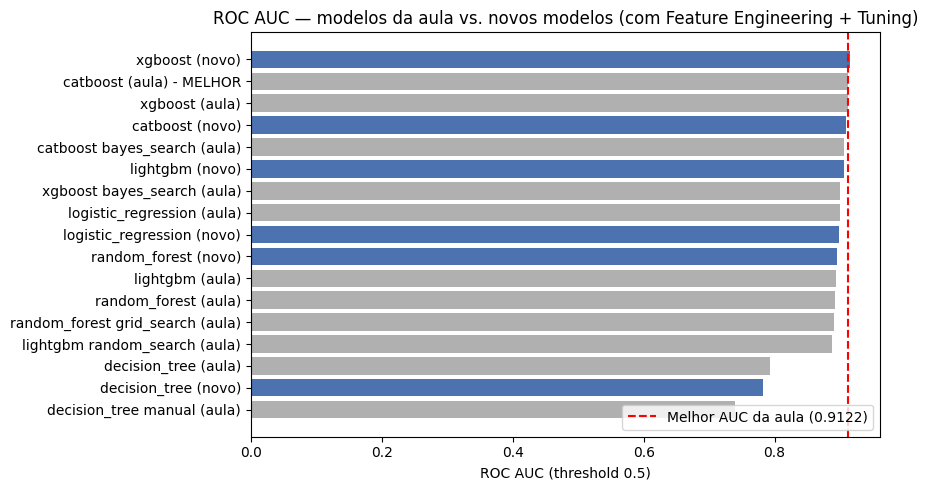

In [25]:
plt.figure(figsize=(9, 5))
plot_df = leaderboard.sort_values("auc")
cores = ["#4C72B0" if "(novo)" in nome else "#B0B0B0" for nome in plot_df["model_name"]]
plt.barh(plot_df["model_name"], plot_df["auc"], color=cores)
plt.axvline(BASELINE_AUC, color="red", linestyle="--", label=f"Melhor AUC da aula ({BASELINE_AUC:.4f})")
plt.xlabel("ROC AUC (threshold 0.5)")
plt.title("ROC AUC — modelos da aula vs. novos modelos (com Feature Engineering + Tuning)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Métricas completas do melhor modelo novo (threshold 0.5 e melhor threshold de negócio)

In [26]:
novos_resultados_df[novos_resultados_df["model_name"] == melhor_novo["model_name"]]

,model_name,threshold_label,threshold,precision,recall,f1,auc
8,xgboost (novo),default_0.5,0.5,0.727273,0.477612,0.576577,0.915266
9,xgboost (novo),best_business_threshold,0.4,0.693878,0.507463,0.586207,0.915266


## 11. Conclusão

- As features agregadas criadas a partir da EDA (`TotalMnt`, `TotalPurchases`,
  `TotalAcceptedCmp`, `Income_per_Person`, entre outras) resumem em poucas colunas o sinal que
  antes estava espalhado em muitas variáveis correlacionadas, e a limpeza dos 4 outliers de
  cadastro removeu ruído sem custo relevante de dados.
- A principal correção de método em relação à aula foi o `scoring` do tuning: buscar o melhor
  `roc_auc` diretamente, em vez de `precision`.
- A comparação final acima mostra, lado a lado, os modelos da aula e os novos modelos nas
  quatro métricas pedidas (Precision, Recall, F1-score e ROC AUC), com o resultado do desafio
  calculado automaticamente na célula anterior.